# Адаменко Семён Сергеевич, ИВТ 2.1
## Программирование 6, лаб 1

### Задание 1.1

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

marketing_data = pd.read_csv('./MarketingSpend.csv', header=0, names=['Date', 'Offline', 'Online'])
retail_data = pd.read_csv('./Retail.csv')


In [18]:

print("статистика по online spend:")
print(f"максимальное значение: {marketing_data['Online'].max()}")
print(f"минимальное значение: {marketing_data['Online'].min()}")
print(f"среднее значение: {marketing_data['Online'].mean():.3f}")
print(f"медиана: {marketing_data['Online'].median():.3f}")
print(f"стандартное отклонение (std): {marketing_data['Online'].std():.3f}")
print(f"дисперсия: {marketing_data['Online'].var():.3f}")

print("\nстатистика по offline spend:")
print(f"максимальное значение: {marketing_data['Offline'].max()}")
print(f"минимальное значение: {marketing_data['Offline'].min()}")
print(f"среднее значение: {marketing_data['Offline'].mean():.3f}")
print(f"медиана: {marketing_data['Offline'].median():.3f}")
print(f"стандартное отклонение (std): {marketing_data['Offline'].std():.3f}")
print(f"дисперсия: {marketing_data['Offline'].var():.3f}")

print("\nобщая статистика по marketingSpend.csv:")
print(marketing_data.describe())

статистика по online spend:
максимальное значение: 4556.93
минимальное значение: 320.25
среднее значение: 1905.881
медиана: 1881.940
стандартное отклонение (std): 808.857
дисперсия: 654249.409

статистика по offline spend:
максимальное значение: 5000
минимальное значение: 500
среднее значение: 2843.562
медиана: 3000.000
стандартное отклонение (std): 952.292
дисперсия: 906860.906

общая статистика по marketingSpend.csv:
           Offline       Online
count   365.000000   365.000000
mean   2843.561644  1905.880740
std     952.292448   808.856853
min     500.000000   320.250000
25%    2500.000000  1258.600000
50%    3000.000000  1881.940000
75%    3500.000000  2435.120000
max    5000.000000  4556.930000


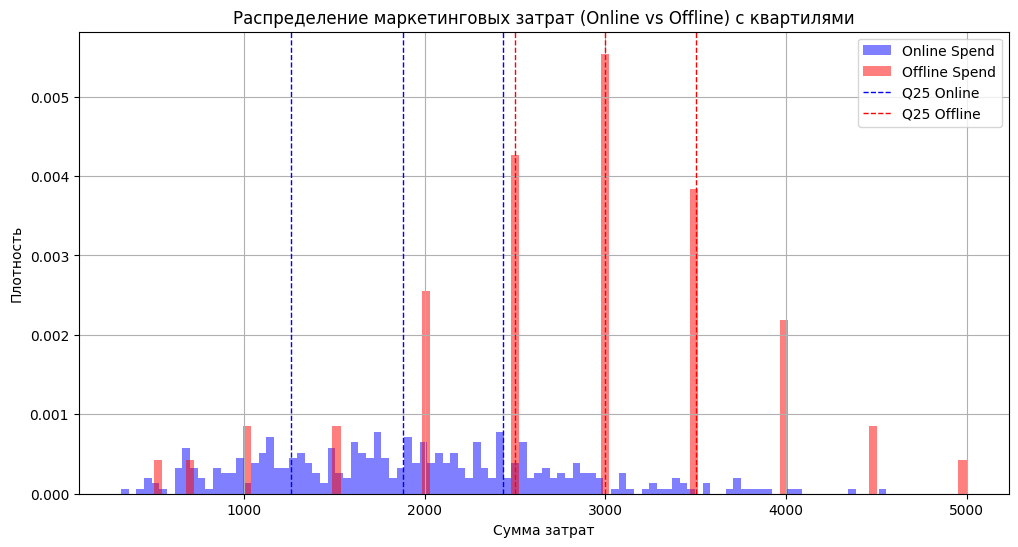

--------------------------------------------------------------------------------

Общая статистика по Retail.csv:
           InvoiceNo      StockCode       Quantity
count  181247.000000  181247.000000  181247.000000
mean   557388.037297   21355.529625       4.560920
std     12905.503448    1362.139130      20.333066
min    536598.000000   10002.000000       1.000000
25%    545700.000000   21135.000000       1.000000
50%    557026.000000   21672.000000       1.000000
75%    568703.000000   22055.000000       2.000000
max    580137.000000   22314.000000     900.000000

Количество уникальных инвойсов: 16522
Общее количество заказанных позиций (Quantity): 826653
Количество уникальных товаров (StockCode): 1178

Топ-10 самых заказываемых товаров (StockCode):
StockCode
20725    1549
22197    1357
21212    1325
20727    1281
21931    1162
20728    1145
22086    1083
15056    1070
20724    1022
20726    1009
Name: count, dtype: int64
-------------------------------------------------------------

In [19]:
plt.figure(figsize=(12, 6))

# Гистограмма Online и Offline затрат
marketing_data['Online'].hist(bins=100, alpha=0.5, color='blue', label='Online Spend', density=True)
marketing_data['Offline'].hist(bins=100, alpha=0.5, color='red', label='Offline Spend', density=True)

# Добавление линий квартилей
for q in [0.25, 0.5, 0.75]:
    plt.axvline(x=marketing_data['Online'].quantile(q), color='blue', linestyle='dashed', linewidth=1, label=f'Q{int(q * 100)} Online' if q == 0.25 else "")
    plt.axvline(x=marketing_data['Offline'].quantile(q), color='red', linestyle='dashed', linewidth=1, label=f'Q{int(q * 100)} Offline' if q == 0.25 else "")

plt.title("Распределение маркетинговых затрат (Online vs Offline) с квартилями")
plt.xlabel("Сумма затрат")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)
plt.show()

print('-' * 80)

# Статистика Retail.csv
print("\nОбщая статистика по Retail.csv:")
print(retail_data.describe())

# Количество уникальных инвойсов
num_invoices = retail_data['InvoiceNo'].nunique()
print(f"\nКоличество уникальных инвойсов: {num_invoices}")

# Общее количество заказанных товаров (Quantity)
total_quantity = retail_data['Quantity'].sum()
print(f"Общее количество заказанных позиций (Quantity): {total_quantity}")

# Количество уникальных товаров (StockCode)
num_stockcodes = retail_data['StockCode'].nunique()
print(f"Количество уникальных товаров (StockCode): {num_stockcodes}")

# Топ-10 самых заказываемых товаров
top_10_stockcodes = retail_data['StockCode'].value_counts().head(10)
print("\nТоп-10 самых заказываемых товаров (StockCode):")
print(top_10_stockcodes)

print('-' * 80)

### Задание 1.2

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

marketing_data = pd.read_csv('./MarketingSpend.csv', header=0, names=['Date', 'Offline', 'Online'], parse_dates=['Date'])
retail_data = pd.read_csv('./Retail.csv', parse_dates=['InvoiceDate'])


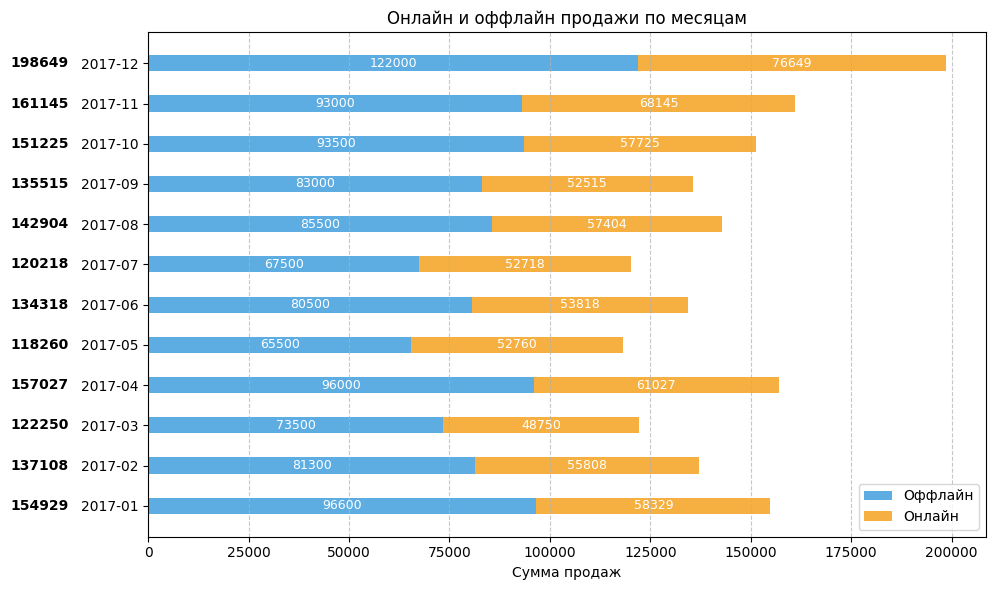

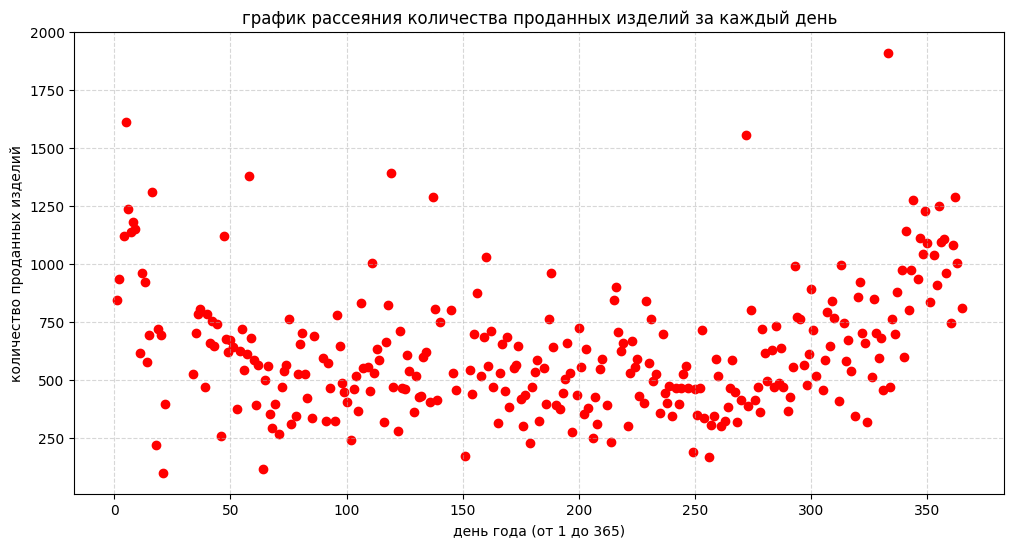

In [21]:
# """ 1 graph """

# marketing_data['Month'] = marketing_data['Date'].dt.strftime('%Y-%m')
# monthly_sales = marketing_data.groupby('Month')[['Offline', 'Online']].sum()

# fig, ax = plt.subplots(figsize=(10, 6))
# bar_height = 0.4
# months = range(len(monthly_sales))

# ax.barh(months, monthly_sales['Offline'], height=bar_height, label='offline spend', color='blue')
# ax.barh(months, monthly_sales['Online'], height=bar_height, left=monthly_sales['Offline'], label='online spend', color='red')

# for i, (offline, online) in enumerate(zip(monthly_sales['Offline'], monthly_sales['Online'])):
#     ax.text(offline / 2, i, f'{offline:.0f}', va='center', ha='center', color='white', fontsize=9)
#     ax.text(offline + online / 2, i, f'{online:.0f}', va='center', ha='center', color='white', fontsize=9)
#     ax.text(-max(monthly_sales['Offline'] + monthly_sales['Online']) * 0.1, i, f'{offline + online:.0f}', va='center', ha='right', color='black', fontsize=10, fontweight='bold')

# ax.set_yticks(months)
# ax.set_yticklabels(monthly_sales.index)
# ax.set_xlabel('сумма продаж')
# ax.set_title('Зависимость онлайн/оффлайн продаж по месяцам')
# ax.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()



# Преобразуем дату и группируем
marketing_data['Month'] = marketing_data['Date'].dt.strftime('%Y-%m')
monthly_sales = marketing_data.groupby('Month')[['Offline', 'Online']].sum()

fig, ax = plt.subplots(figsize=(10, 6))
bar_height = 0.4
months = range(len(monthly_sales))

# Мягкие цвета
offline_color = '#5DADE2'  # голубой
online_color = '#F5B041'   # оранжево-золотой

ax.barh(months, monthly_sales['Offline'], height=bar_height, label='Оффлайн', color=offline_color)
ax.barh(months, monthly_sales['Online'], height=bar_height, left=monthly_sales['Offline'], label='Онлайн', color=online_color)

for i, (offline, online) in enumerate(zip(monthly_sales['Offline'], monthly_sales['Online'])):
    ax.text(offline / 2, i, f'{offline:.0f}', va='center', ha='center', color='white', fontsize=9)
    ax.text(offline + online / 2, i, f'{online:.0f}', va='center', ha='center', color='white', fontsize=9)
    ax.text(-max(monthly_sales['Offline'] + monthly_sales['Online']) * 0.1, i, f'{offline + online:.0f}', va='center', ha='right', color='black', fontsize=10, fontweight='bold')

ax.set_yticks(months)
ax.set_yticklabels(monthly_sales.index)
ax.set_xlabel('Сумма продаж')
ax.set_title('Онлайн и оффлайн продажи по месяцам')
ax.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

""" 2 graph """
daily_sales = retail_data.groupby('InvoiceDate')['StockCode'].count().reset_index()
daily_sales['DayOfYear'] = daily_sales['InvoiceDate'].dt.dayofyear

plt.figure(figsize=(12, 6))
plt.scatter(daily_sales['DayOfYear'], daily_sales['StockCode'], color='red', alpha=1)
plt.xlabel('день года (от 1 до 365)')
plt.ylabel('количество проданных изделий')
plt.title('график рассеяния количества проданных изделий за каждый день')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()